# ECG Rhythm Classification with a 1D Convolutional Neural Network (merged classes)

Single-lead ECG rhythm classifier (Keras 3 with the PyTorch backend) trained on the
**Chapman–Shaoxing** 12-lead ECG database, using **lead I only** to emulate
smartwatch-grade single-lead recordings.

**Task** — 5-class rhythm classification with two clinically-motivated merges:
`SRSA` (sinus rhythm + sinus irregularity), `AFIBAF` (atrial fibrillation + flutter),
`SB` (sinus bradycardia), `SVT` (supraventricular tachycardia), `ST` (sinus tachycardia).

The merges combine rhythms that are clinically similar and **not reliably separable on
a single lead** (SR↔SA, AFIB↔AF). Both merged pairs share the same screening-level
clinical action, so the merge is a deliberate, justified design choice — and it lets the
model cover ~98.6 % of the dataset instead of 90.7 %.

**Pipeline** — per-record z-score scaling → stratified 80/10/10 train/validation/test
split → 1D-CNN → EarlyStopping on the validation set (test set kept untouched) →
evaluation with per-class precision / recall / F1 and macro-F1.

**Data** — Chapman–Shaoxing 12-lead ECG database (Zheng et al., 2020). The source used
here is the original **ChapmanECG** collection on figshare:
https://figshare.com/collections/ChapmanECG/4560497 .
A larger, merged *Chapman-Shaoxing-Ningbo* version is also available on PhysioNet
(https://doi.org/10.13026/wgex-er52). The raw data is **not** redistributed in this
repository; see the README for how to download it (`Diagnostics.xlsx` and the
`ECGData/` folder are expected next to this notebook).

> ⚠️ Research / educational project. **Not a medical device and not for clinical use.**

## 1. Setup and configuration

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # use the PyTorch backend for Keras 3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

keras.utils.set_random_seed(0)          # reproducibility

# --- Configuration -------------------------------------------------------
N_SAMPLES   = 5000                       # samples per record (10 s at 500 Hz)
N_LEADS     = 1                          # number of leads used (lead I only)
LEAD_INDEX  = 0                          # first lead column in the CSV files

# Raw rhythm labels loaded from the dataset (7 source rhythms)
SOURCE_RHYTHMS = ["SR", "AFIB", "SB", "SVT", "ST", "AF", "SA"]

# Merge clinically-similar rhythms that are not separable on a single lead:
#   SR + SA   -> "SRSA"    (sinus rhythm + sinus irregularity; both benign sinus)
#   AFIB + AF -> "AFIBAF"  (atrial fibrillation + flutter; same screening action)
MERGE = {"SR": "SRSA", "SA": "SRSA",
         "AFIB": "AFIBAF", "AF": "AFIBAF",
         "SB": "SB", "SVT": "SVT", "ST": "ST"}

RHYTHMS   = ["SRSA", "AFIBAF", "SB", "SVT", "ST"]   # final (merged) classes
N_CLASSES = len(RHYTHMS)

# Class-weighting switch (off by default; merged classes restore balance).
USE_WEIGHTS = False

print("Keras", keras.__version__, "| backend:", keras.config.backend())

Keras 3.14.1 | backend: torch


## 2. Data loading and dataset construction

In [2]:
# Map each MERGED class name to an integer class index
LABEL = {name: i for i, name in enumerate(RHYTHMS)}

# Diagnosis table: file name -> raw rhythm label
diagnostics = pd.read_excel("Diagnostics.xlsx", usecols=["FileName", "Rhythm"])

# Keep all source rhythms, then map each to its merged class
subset = diagnostics[diagnostics["Rhythm"].isin(SOURCE_RHYTHMS)].reset_index(drop=True)
subset["MergedClass"] = subset["Rhythm"].map(MERGE)
print(subset["MergedClass"].value_counts(), "\n")

# Load the raw single-lead signals into the feature matrix X and labels y
lead_cols = list(range(LEAD_INDEX, LEAD_INDEX + N_LEADS))
X = np.zeros((len(subset), N_LEADS * N_SAMPLES), dtype=float)
y = np.zeros((len(subset),), dtype=int)

for i, row in subset.iterrows():
    record = pd.read_csv(f"ECGData/{row['FileName']}.csv",
                         header=0, usecols=lead_cols, nrows=N_SAMPLES)
    X[i] = record.values.T.flatten()
    y[i] = LABEL[row["MergedClass"]]

y = y.reshape(-1, 1)
print("X:", X.shape, " y:", y.shape)

MergedClass
SB        3889
AFIBAF    2225
SRSA      2225
ST        1568
SVT        587
Name: count, dtype: int64 

X: (10494, 5000)  y: (10494, 1)


## 3. Per-record scaling (z-score)

Each ECG record is standardised independently (zero mean, unit variance).

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
for i in range(len(X)):
    X[i] = scaler.fit_transform(X[i].reshape(-1, 1)).ravel()

## 4. One-hot encoding of the labels

In [4]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
Y = ohe.fit_transform(y).toarray()      # dense one-hot matrix, shape (n, N_CLASSES)
print("Y:", Y.shape)

Y: (10494, 5)


## 5. Train / validation / test split (80 / 10 / 10, stratified)

In [5]:
from sklearn.model_selection import train_test_split

# Three independent subsets:
#   train      - fits the model weights
#   validation - drives EarlyStopping (decides which epoch to keep)
#   test       - independent final estimate, touched only once at the very end
# EarlyStopping must NOT monitor the test set, otherwise it stops being independent.

y_int = np.argmax(Y, axis=1)            # integer labels (for stratification)

X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, Y, test_size=0.10, random_state=0, stratify=y_int)

y_int_full = np.argmax(Y_train_full, axis=1)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.1111, random_state=0, stratify=y_int_full)

print("Train:", X_train.shape[0], " Val:", X_val.shape[0], " Test:", X_test.shape[0])

Train: 8394  Val: 1050  Test: 1050


## 6. Model definition and training

Class imbalance was evaluated with an A/B test (training with vs without class
weighting). For this 5-class setup it gave no measurable benefit, so weighting is
disabled by default and exposed through the `USE_WEIGHTS` switch in the
configuration cell above.

In [6]:
from keras.models import Sequential
from keras.layers import (Conv1D, Dense, MaxPooling1D,
                          GlobalAveragePooling1D, Input, SpatialDropout1D)
from keras.callbacks import EarlyStopping

# --- Architecture: 1D CNN ------------------------------------------------
model = Sequential([
    Input(shape=(N_LEADS * N_SAMPLES, 1)),

    Conv1D(filters=32, kernel_size=171, activation="relu"),
    MaxPooling1D(pool_size=11, padding="same"),
    SpatialDropout1D(0.25),

    Conv1D(filters=64, kernel_size=11, padding="same", activation="relu"),
    MaxPooling1D(pool_size=5, padding="same"),
    SpatialDropout1D(0.43),

    Conv1D(filters=128, kernel_size=5, padding="same", activation="relu"),
    SpatialDropout1D(0.43),

    GlobalAveragePooling1D(),
    Dense(N_CLASSES, activation="softmax"),
])

# --- Optional class weighting (controlled by USE_WEIGHTS) ----------------
if USE_WEIGHTS:
    from sklearn.utils.class_weight import compute_class_weight
    y_train_int = np.argmax(Y_train, axis=1)
    weights = compute_class_weight(class_weight="balanced",
                                   classes=np.unique(y_train_int), y=y_train_int)
    class_weight = dict(enumerate(weights))
    print("Class weighting ON:", class_weight)
else:
    class_weight = None
    print("Class weighting OFF")

# --- Training with EarlyStopping on the validation set -------------------
early_stop = EarlyStopping(monitor="val_loss", patience=100,
                           restore_best_weights=True, verbose=1)

model.compile(optimizer="adamw", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, Y_train,
                    validation_data=(X_val, Y_val),
                    epochs=800, batch_size=256, verbose=1,
                    class_weight=class_weight,
                    callbacks=[early_stop])

print("\nTrained epochs:", len(history.history["loss"]),
      "| best epoch:", int(np.argmin(history.history["val_loss"])) + 1)

Class weighting OFF
Epoch 1/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3575 - loss: 1.4692 - val_accuracy: 0.3705 - val_loss: 1.3537
Epoch 2/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4332 - loss: 1.2885 - val_accuracy: 0.6095 - val_loss: 1.0875
Epoch 3/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5527 - loss: 1.0491 - val_accuracy: 0.7362 - val_loss: 0.7912
Epoch 4/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6471 - loss: 0.8618 - val_accuracy: 0.8219 - val_loss: 0.5858
Epoch 5/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7183 - loss: 0.7094 - val_accuracy: 0.8486 - val_loss: 0.4574
Epoch 6/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7635 - loss: 0.6015 - val_accuracy: 0.8724 - val_loss: 0.3990
Epoch 7/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8075 - loss: 0.5147 - val_accuracy: 0.8810 - val_loss: 0.3460
Epoch 8/800
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8300 - loss: 0.459

## 7. Training history

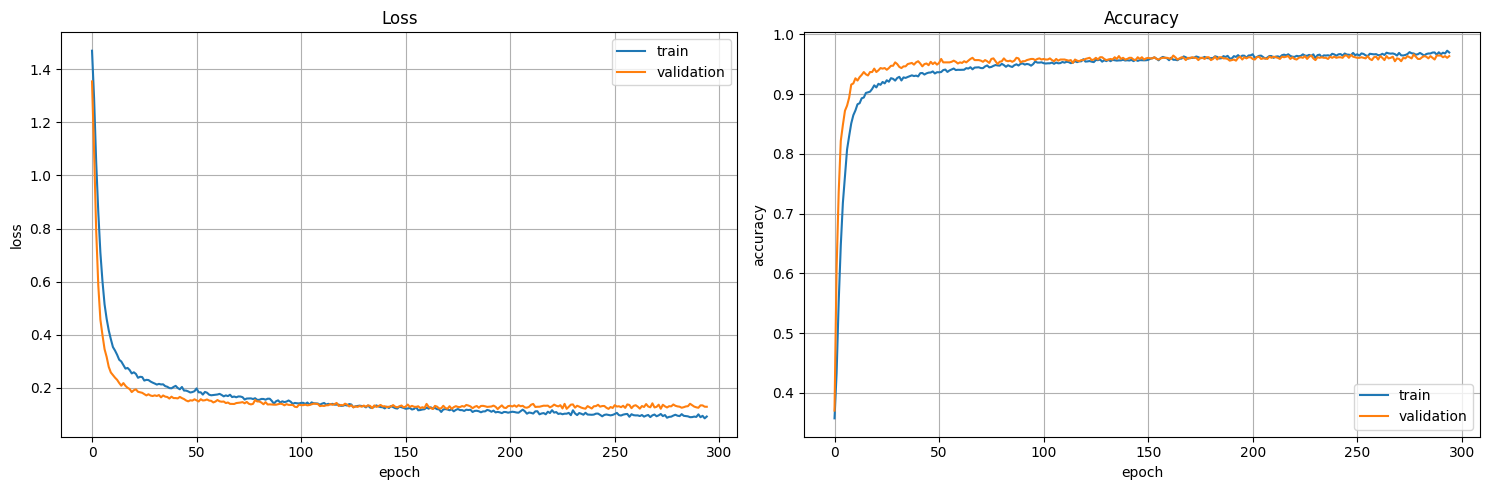

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
ax[1].legend(); ax[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Confusion matrix — training set

In [8]:
from sklearn.metrics import confusion_matrix

y_pred_train = np.argmax(model.predict(X_train), axis=1)
y_true_train = np.argmax(Y_train, axis=1)

cm_train = confusion_matrix(y_true_train, y_pred_train, normalize="true")
print("Row-normalised confusion matrix [%]  (rows = true, cols = predicted)")
print("classes:", RHYTHMS)
print(np.round(100 * cm_train, 1))

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Row-normalised confusion matrix [%]  (rows = true, cols = predicted)
classes: ['SRSA', 'AFIBAF', 'SB', 'SVT', 'ST']
[[97.   0.4  2.   0.   0.6]
 [ 0.2 96.5  0.   2.7  0.6]
 [ 0.2  0.1 99.7  0.   0. ]
 [ 0.   1.5  0.  98.3  0.2]
 [ 0.4  0.9  0.1  0.1 98.6]]


## 9. Confusion matrix — test set

In [9]:
y_pred_test = np.argmax(model.predict(X_test), axis=1)
y_true_test = np.argmax(Y_test, axis=1)

cm_test = confusion_matrix(y_true_test, y_pred_test, normalize="true")
print("Row-normalised confusion matrix [%]  (rows = true, cols = predicted)")
print("classes:", RHYTHMS)
print(np.round(100 * cm_test, 1))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Row-normalised confusion matrix [%]  (rows = true, cols = predicted)
classes: ['SRSA', 'AFIBAF', 'SB', 'SVT', 'ST']
[[91.   2.2  5.4  0.   1.3]
 [ 0.9 93.7  0.5  2.7  2.3]
 [ 0.3  0.8 99.   0.   0. ]
 [ 0.   5.1  0.  91.5  3.4]
 [ 0.   3.8  0.   1.3 94.9]]


## 10. Test-set metrics (precision / recall / F1 / macro-F1)

In [10]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_true_test, y_pred_test, target_names=RHYTHMS, digits=3))

macro_f1    = f1_score(y_true_test, y_pred_test, average="macro")
weighted_f1 = f1_score(y_true_test, y_pred_test, average="weighted")
print(f"MACRO-F1   : {macro_f1*100:.2f} %")
print(f"WEIGHTED-F1: {weighted_f1*100:.2f} %\n")

# Absolute confusion matrix + manual per-class breakdown
# (absolute counts are needed to read precision = false-alarm rate)
cm = confusion_matrix(y_true_test, y_pred_test)
print("Absolute confusion matrix (rows = true, cols = predicted):")
print("classes:", RHYTHMS)
print(cm, "\n")

print(f"{'class':6}{'recall':>9}{'precision':>11}{'specificity':>13}{'F1':>8}{'support':>9}")
total = cm.sum()
for i, name in enumerate(RHYTHMS):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP            # rest of the row  = misses
    FP = cm[:, i].sum() - TP            # rest of the col  = false alarms
    TN = total - TP - FN - FP
    recall      = TP / (TP + FN) if (TP + FN) else 0.0
    precision   = TP / (TP + FP) if (TP + FP) else 0.0
    specificity = TN / (TN + FP) if (TN + FP) else 0.0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    print(f"{name:6}{recall*100:8.1f}%{precision*100:10.1f}%"
          f"{specificity*100:12.1f}%{f1*100:7.1f}%{TP+FN:9d}")

              precision    recall  f1-score   support

        SRSA      0.985     0.910     0.946       223
      AFIBAF      0.924     0.937     0.931       222
          SB      0.967     0.990     0.978       389
         SVT      0.871     0.915     0.893        59
          ST      0.937     0.949     0.943       157

    accuracy                          0.951      1050
   macro avg      0.937     0.940     0.938      1050
weighted avg      0.952     0.951     0.951      1050

MACRO-F1   : 93.82 %
WEIGHTED-F1: 95.14 %

Absolute confusion matrix (rows = true, cols = predicted):
classes: ['SRSA', 'AFIBAF', 'SB', 'SVT', 'ST']
[[203   5  12   0   3]
 [  2 208   1   6   5]
 [  1   3 385   0   0]
 [  0   3   0  54   2]
 [  0   6   0   2 149]] 

class    recall  precision  specificity      F1  support
SRSA      91.0%      98.5%        99.6%   94.6%      223
AFIBAF    93.7%      92.4%        97.9%   93.1%      222
SB        99.0%      96.7%        98.0%   97.8%      389
SVT       91.5% 